<a href="https://colab.research.google.com/github/wawaelenti/Machine-Learning/blob/main/DBSCAN_Euclidean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📐 1. Formulasi Matematis Euclidean Distance & Prinsip DBSCAN

### 1.1. Euclidean Distance
Jarak yang digunakan untuk menentukan tetangga:
$$d(x,y)=\sqrt{\sum_{i=1}^{p}(x_i-y_i)^2}.$$

### 1.2. Lingkungan Kepadatan
DBSCAN membentuk lingkungan radius $\varepsilon$:
$$N_\varepsilon(x)=\{y:d(x,y)\leq\varepsilon\}.$$
Titik menjadi **core point** ketika $|N_\varepsilon(x)|\geq\mathrm{min\_samples}$,
dengan titik itu sendiri ikut dihitung. **Border point** berada dalam
jangkauan core point, tetapi tidak memenuhi jumlah minimum tetangga.
Label `-1` menunjukkan **noise**.

Semua baris dan fitur hasil StandardScaler digunakan untuk clustering.
Silhouette memakai seluruh data non-noise dan metrik jarak yang sama,
ketika jumlah klaster memenuhi syarat. PCA diterapkan untuk visualisasi.

In [ ]:
# =======================================================================
# 1. SETUP & IMPORT LIBRARY
# =======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120


In [ ]:
# =======================================================================
# 2. DATASET & PREPROCESSING
# =======================================================================
FILE = 'dataset_B_05_2020 (1).csv'
df = pd.read_csv(FILE)

print('Shape dataset:', df.shape)
print('Jumlah data:', df.shape[0])
print('Jumlah kolom:', df.shape[1])
display(df.head(3))

# Metadata dan label asli disimpan terpisah dari fitur clustering.
urls = df['url'].copy()
y_true = df['status'].copy()
labels = y_true.copy()
X = df.drop(columns=['url', 'status']).select_dtypes(include=np.number)
print('Shape fitur numerik:', X.shape)

# Imputasi median, penghapusan fitur konstan, lalu StandardScaler.
print('Missing value sebelum imputasi:', int(X.isna().sum().sum()))
X = X.fillna(X.median())
print('Missing value setelah imputasi:', int(X.isna().sum().sum()))

selector = VarianceThreshold(threshold=0)
X_sel = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()]
removed_features = X.columns[~selector.get_support()]
X_selected = pd.DataFrame(X_sel, columns=selected_features, index=X.index)
print('Fitur konstan yang dihapus:', list(removed_features))
print('Shape setelah seleksi fitur:', X_selected.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
df_after = pd.DataFrame(X_scaled, columns=selected_features, index=X.index)
print('Shape setelah StandardScaler:', X_scaled.shape)
display(df_after.head(3))


Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing


Shape fitur numerik: (11430, 87)
Missing value sebelum imputasi: 0
Missing value setelah imputasi: 0
Fitur konstan yang dihapus: ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']
Shape setelah seleksi fitur: (11430, 81)
Shape setelah StandardScaler: (11430, 81)


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
0,-0.436327,-0.193964,-0.421020,0.379116,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,-1.860473,1.129194,-0.28037,-0.549299,-1.307594,-0.429340,6.978227,0.934264,0.320974
1,0.287067,0.177207,2.375182,-1.081136,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,0.537498,-0.885587,-0.28037,-0.510022,0.548471,-0.429340,-0.143303,0.934264,-0.467407
2,1.173224,2.682613,2.375182,1.109242,0.001174,-0.142915,2.356473,2.237556,2.711505,1.534217,...,-0.377549,0.537498,-0.885587,-0.28037,-0.587348,-0.018839,2.491612,-0.143303,0.934264,-1.255788


## 📈 2. Penetapan Parameter DBSCAN

Parameter notebook awal dipertahankan: `EPS = 0.5`, `MIN_SAMPLES = 5`,
`algorithm="brute"`, dan `n_jobs=1`.
`EPS` menentukan radius lingkungan; `MIN_SAMPLES` menentukan kepadatan
minimum. Jumlah klaster diperoleh dari hubungan kepadatan data.

In [ ]:
# =======================================================================
# 3. PARAMETER DBSCAN
# =======================================================================
DISTANCE_METRIC = 'euclidean'
EPS = 0.5
MIN_SAMPLES = 5
print('Metrik jarak:', DISTANCE_METRIC)
print('EPS:', EPS)
print('MIN_SAMPLES:', MIN_SAMPLES)


Metrik jarak: euclidean
EPS: 0.5
MIN_SAMPLES: 5


In [ ]:
# =======================================================================
# 4. EKSEKUSI CLUSTERING DBSCAN
# =======================================================================
dbscan = DBSCAN(
    eps=EPS,
    min_samples=MIN_SAMPLES,
    metric=DISTANCE_METRIC,
    algorithm="brute",
    n_jobs=1
)

cluster_labels = dbscan.fit_predict(X_scaled)

print("Jumlah label cluster:", len(cluster_labels))


Jumlah label cluster: 11430


In [ ]:
# =======================================================================
# 5. HASIL KLASTER, NOISE, & METRIK EVALUASI
# =======================================================================
noise_mask = cluster_labels == -1
core_mask = np.zeros(len(cluster_labels), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
border_mask = (~noise_mask) & (~core_mask)

n_clusters = len(set(cluster_labels)) - int(noise_mask.any())
n_noise = int(noise_mask.sum())

print("Metrik jarak:", DISTANCE_METRIC)
print("Jumlah cluster (tanpa noise):", n_clusters)
print("Jumlah core point:", int(core_mask.sum()))
print("Jumlah border point:", int(border_mask.sum()))
print("Jumlah noise:", n_noise)
print(f"Persentase noise: {100 * noise_mask.mean():.2f}%")

cluster_counts = (
    pd.Series(cluster_labels, name="Cluster")
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Jumlah Data")
)

cluster_counts["Persentase (%)"] = (
    cluster_counts["Jumlah Data"] / len(cluster_labels) * 100
).round(2)

display(cluster_counts)

X_evaluation = X_scaled[~noise_mask]
labels_evaluation = cluster_labels[~noise_mask]
n_evaluation_clusters = len(np.unique(labels_evaluation))

silhouette = None

if 2 <= n_evaluation_clusters < len(labels_evaluation):
    silhouette = silhouette_score(
        X_evaluation,
        labels_evaluation,
        metric=DISTANCE_METRIC
    )
    print("Jumlah data evaluasi (seluruh data non-noise):", len(labels_evaluation))
    print("Jumlah cluster pada data evaluasi:", n_evaluation_clusters)
    print(f"Silhouette score ({DISTANCE_METRIC}): {silhouette:.4f}")
else:
    print("Silhouette tidak dihitung: data evaluasi tidak memenuhi syarat jumlah cluster.")

eval_df = pd.DataFrame([{
    'Distance Metric': DISTANCE_METRIC.title(),
    'EPS': EPS,
    'MIN_SAMPLES': MIN_SAMPLES,
    'Jumlah Klaster': n_clusters,
    'Core Point': int(core_mask.sum()),
    'Border Point': int(border_mask.sum()),
    'Noise': n_noise,
    'Noise (%)': 100 * noise_mask.mean(),
    'Silhouette Score': silhouette if silhouette is not None else np.nan,
}])
display(eval_df.round(4))


Metrik jarak: euclidean
Jumlah cluster (tanpa noise): 58
Jumlah core point: 509
Jumlah border point: 120
Jumlah noise: 10801
Persentase noise: 94.50%


,Cluster,Jumlah Data,Persentase (%)
0,-1,10801,94.50
1,0,39,0.34
2,1,18,0.16
3,2,16,0.14
4,3,12,0.10
5,4,51,0.45
6,5,5,0.04
7,6,39,0.34
8,7,8,0.07
9,8,12,0.10


Jumlah data evaluasi (seluruh data non-noise): 629
Jumlah cluster pada data evaluasi: 58
Silhouette score (euclidean): 0.6842


,Distance Metric,EPS,MIN_SAMPLES,Jumlah Klaster,Core Point,Border Point,Noise,Noise (%),Silhouette Score
0,Euclidean,0.5,5,58,509,120,10801,94.4969,0.6842


Total explained variance PCA: 15.51%


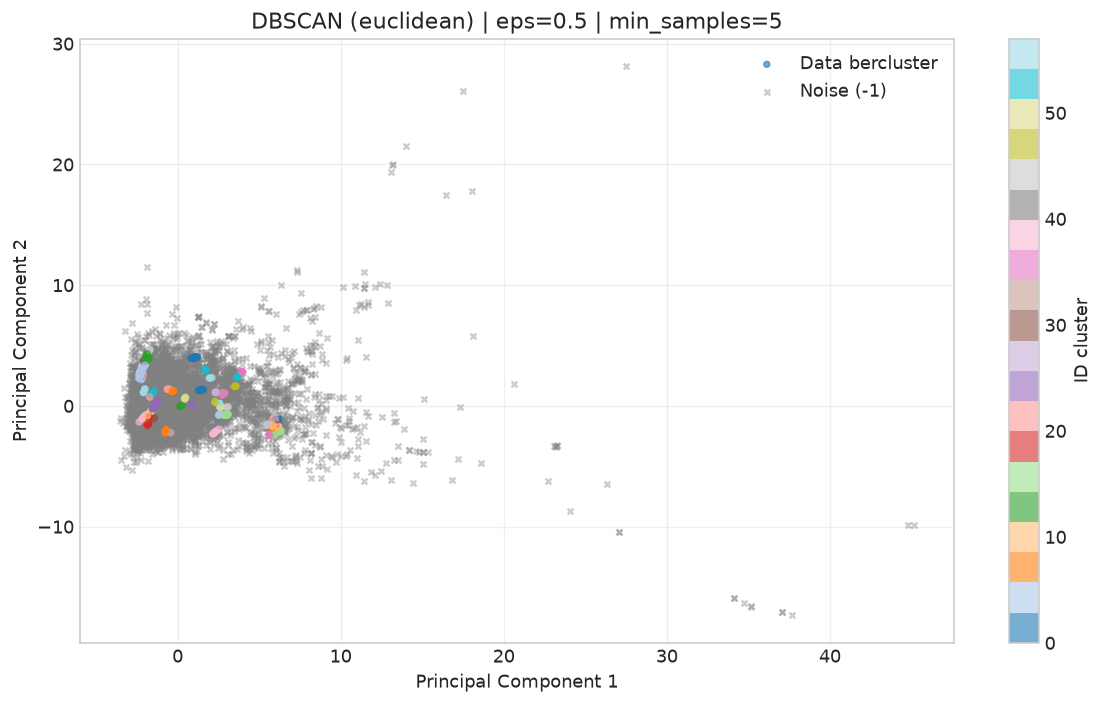

In [ ]:
# =======================================================================
# 6. VISUALISASI PCA 2D PEMETAAN KLASTER & NOISE
# =======================================================================
pca = PCA(n_components=2, svd_solver="full", random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Total explained variance PCA: {pca.explained_variance_ratio_.sum():.2%}")

fig, ax = plt.subplots(figsize=(10, 6))

if (~noise_mask).any():
    points = ax.scatter(
        X_pca[~noise_mask, 0],
        X_pca[~noise_mask, 1],
        c=cluster_labels[~noise_mask],
        cmap="tab20",
        s=12,
        alpha=0.6,
        zorder=2,
        label="Data bercluster"
    )
    if n_clusters > 1:
        fig.colorbar(
            points,
            ax=ax,
            label="ID cluster",
            ticks=np.unique(cluster_labels[~noise_mask]) if n_clusters <= 10 else None
        )

if noise_mask.any():
    ax.scatter(
        X_pca[noise_mask, 0],
        X_pca[noise_mask, 1],
        c="gray",
        marker="x",
        s=12,
        alpha=0.4,
        zorder=1,
        label="Noise (-1)"
    )

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title(
    f"DBSCAN ({DISTANCE_METRIC}) | eps={EPS} | min_samples={MIN_SAMPLES}"
)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
